In [27]:
import numpy as np
import astropy.io.ascii
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
ori = astropy.io.ascii.read("../data/input/tobin2022_orion_pairings.txt").to_pandas()
per = astropy.io.ascii.read("../data/input/tobin2022_perseus_pairings.txt").to_pandas()

In [29]:
ori_keys = {
    'H12-B-A+H12-B-B' : 'HOPS-12',
    'H290-A+H290-B' : 'HOPS-290',
    'H92-B+(H92-A-B+H92-A-A)' : 'HOPS-92',
    'H288-A-B+H288-A-A' : 'HOPS-288',
    'H203-B+H203-A' : 'HOPS-203',
    'HH270VLA1-B+HH270VLA1-A': 'HH270VLA1',
    'H32-B+H32-A' : 'HOPS-32',
    'H84-B+H84-A' : 'HOPS-84',
    'H168-A+H168-B' : 'HOPS-168',
    'H281-B+H281-A' : 'HOPS-281',
    'H312-B+H312-A' : 'HOPS-312',
    'H364-A+H364-B' : 'HOPS-364',
    'H395-B+H395-A' : 'HOPS-395',
    'H400-B+H400-A' : 'HOPS-400',
    'H182-B+H182-A' : 'HOPS-182',
    'H323-B+H323-A' : 'HOPS-323',
    'H282-B+H282-A' : 'HOPS-282',
    'H366-A+H366-B' : 'HOPS-366',
    'H193-B+H193-A' : 'HOPS-193',
    'H304-B+H304-A' : 'HOPS-304',
    # H361-N
    'H384-A+H384-A-B' : 'HOPS-384',
    'H363-B+H363-A' : 'HOPS-363',
    'H173-B+H173-A' : 'HOPS-173',
    'H75-B+H75-A' : 'HOPS-75',
    'H213-A+H213-B' : 'HOPS-213',
}

per_keys = {
    'P2-A-P2-B' : 'Per-emb-2',
    'P12-A-P12-B' : 'Per-emb-12',
    'P17-A-P17-B' : 'Per-emb-17',
    'P18-A-P18-B' : 'Per-emb-18',
    'P22-A-P22-B' : 'Per-emb-22',
    'P27-A-P27-B' : 'Per-emb-27',
    'P33-B-P33-C' : 'Per-emb-33', # 3 sources, also 'P33-A-(P33-B+P33-C)'
    'P35-A-P35-B' : 'Per-emb-35',
    'P36-A-P36-B' : 'Per-emb-36',
    'P44-A-P44-B' : 'Per-emb-44',
}

In [30]:
ori

,Pair,ASep,e_ASep,PSep,e_PSep,log0.87FR,e_log0.87FR,log9FR,e_log9FR,Prob,Class
0,H361-E-A+H361-E-B,0.055,0.015,21.8,6.1,NaN,NaN,-0.49,0.15,1.00,C0+C0
1,H361-C-A+H361-C-B,0.087,0.002,37.6,1.0,NaN,NaN,-0.77,0.01,1.00,C0+C0
2,H85-B+H85-A,0.102,0.001,40.2,0.6,-0.15,0.02,-0.92,0.05,1.00,FS+FS
3,H20-A+H20-B,0.110,0.002,42.9,1.0,-0.98,0.44,-0.50,0.14,1.00,CI+CI
4,H77-A-B+H77-A-A,0.114,0.004,44.6,1.4,-0.08,0.03,NaN,NaN,1.00,FS+FS
...,...,...,...,...,...,...,...,...,...,...,...
152,H210+H211,21.027,0.008,9138.2,3.3,-1.43,0.07,NaN,NaN,0.72,FS+FS
153,J05352074-0515492+[V2358Ori+(H56-B+[(H56-A-A+H...,23.452,0.002,9212.0,0.9,NaN,NaN,NaN,NaN,0.37,N+[N+(C0+[(C0+C0)+C0])]
154,HH270mms2+(HH270mms1-A+HH270mms1-B),22.780,0.003,9415.0,1.3,NaN,NaN,NaN,NaN,0.98,FS+(CI+CI)
155,H252+(H255-A+H255-B),22.077,0.009,9459.9,3.9,NaN,NaN,NaN,NaN,0.56,FS+(FS+FS)


In [31]:
df = pd.concat([ori[ori['Pair'].isin(list(ori_keys.keys()))], per[per['Pair'].isin(list(per_keys.keys()))]]).reset_index(drop=True)

In [32]:
df['Pair'] = df['Pair'].apply(lambda x: {**per_keys, **ori_keys}[x])
df = df[['Pair', 'PSep', 'Class']]
df.to_csv("../data/output/separations.csv",index=False)

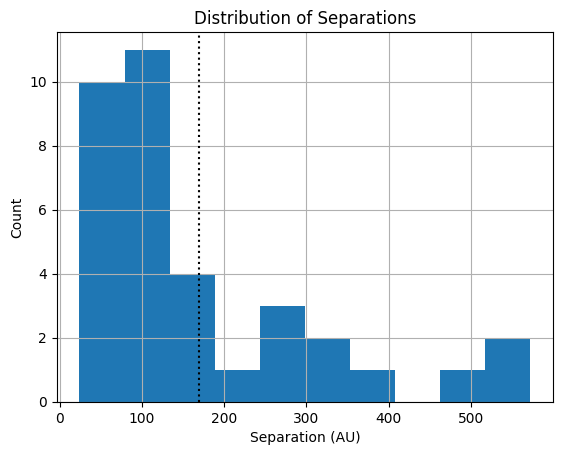

In [33]:
df['PSep'].hist()
plt.xlabel("Separation (AU)")
plt.ylabel("Count")
plt.title("Distribution of Separations")
plt.axvline(np.mean(df['PSep']), c='k', ls='dotted')